<a href="https://colab.research.google.com/github/analauralopescapeletto-sketch/AULA-CN/blob/main/calculo_numerico_ativ3_ANALAURA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **INTEGRANTES**


187065 - ANA LAURA LOPES CAPELETTO



187574 - MARIANA GRIMALDI


185319 - RANIELLY HISSAMORI


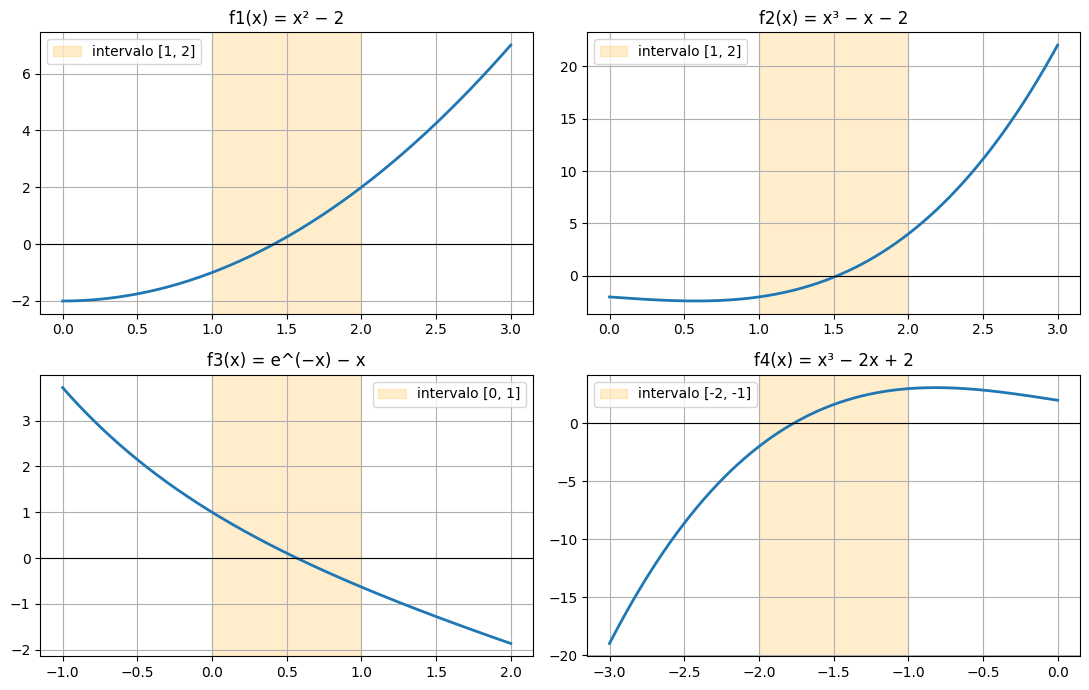

Em cada intervalo a função troca de sinal, então há raiz (Teorema do Valor Intermediário).
Newton  -> raiz = 1.4142135623730951 | iterações = 4 | Convergiu
Valor exato: 1.4142135623730951
| Função   | Método   | Valores iniciais   |   Raiz aproximada |   |f(x)| final | Iterações/resultado      |
|:---------|:---------|:-------------------|------------------:|---------------:|:-------------------------|
| f1       | Bisseção | [1, 2]             |          1.41421  |       2.69e-07 | 21 iterações (convergiu) |
| f1       | Newton   | x0 = 1.5           |          1.41421  |       4.44e-16 | 4 iterações (convergiu)  |
| f1       | Secante  | (1, 2)             |          1.41421  |       8.88e-16 | 6 iterações (convergiu)  |
| f2       | Bisseção | [1, 2]             |          1.52138  |       1.45e-08 | 22 iterações (convergiu) |
| f2       | Newton   | x0 = 1.5           |          1.52138  |       4.53e-14 | 3 iterações (convergiu)  |
| f2       | Secante  | (1, 2)             |     

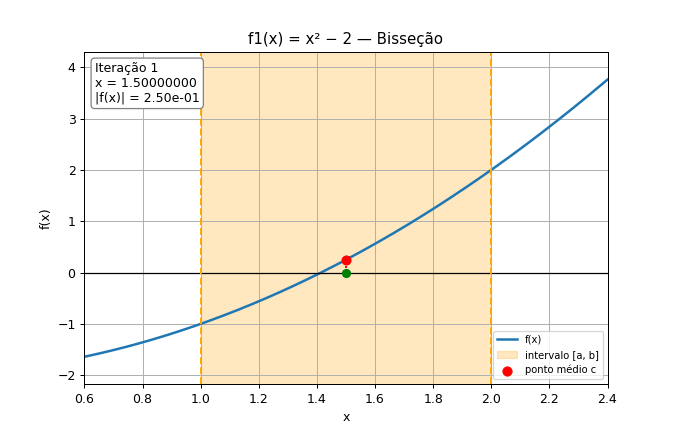

Gerado: anim_f2_newton.gif


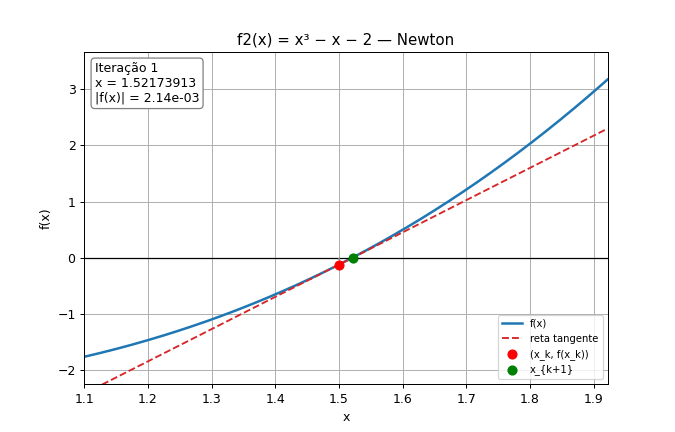

Gerado: anim_f3_secante.gif


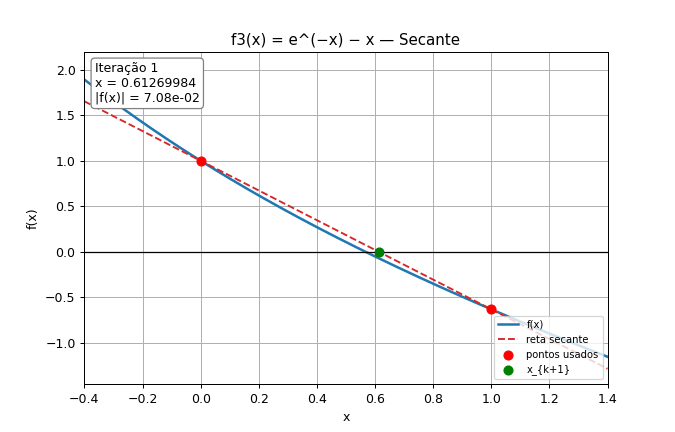

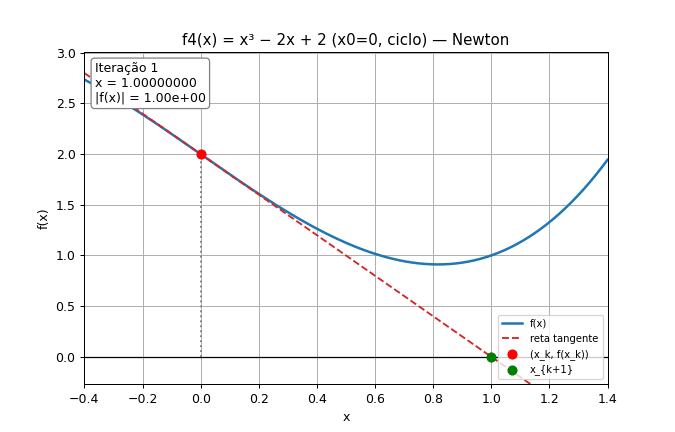

Arquivos no zip: ['anim_f4_newton.gif', 'anim_f4_newton_ciclo.gif', 'anim_f1_secante.gif', 'anim_f4_bissecao.gif', 'anim_f3_bissecao.gif', 'anim_f2_bissecao.gif', 'anim_f1_bissecao.gif', 'anim_f2_secante.gif', 'anim_f3_newton.gif', 'anim_f4_secante.gif', 'anim_f3_secante.gif', 'anim_f1_newton.gif', 'anim_f2_newton.gif', 'tabela_resultados.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:

# ===================== CÉLULA DE CÓDIGO 1 =====================
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

# ---------- PARÂMETROS GLOBAIS (podem ser alterados) ----------
TOL = 1e-6          # tolerância
MAX_ITER = 100      # número máximo de iterações
DERIV_TOL = 1e-12   # |f'(x)| abaixo disso é considerado zero (Newton)
DENOM_TOL = 1e-12   # |f(x_k)-f(x_{k-1})| abaixo disso é considerado zero (secante)


# ===================== CÉLULA DE CÓDIGO 2 =====================
FUNCOES = {
    "f1": {
        "nome": "f1(x) = x² − 2",
        "f":  lambda x: x**2 - 2,
        "df": lambda x: 2*x,
        "intervalo": (1, 2), "x0_newton": 1.5, "par_secante": (1, 2),
    },
    "f2": {
        "nome": "f2(x) = x³ − x − 2",
        "f":  lambda x: x**3 - x - 2,
        "df": lambda x: 3*x**2 - 1,
        "intervalo": (1, 2), "x0_newton": 1.5, "par_secante": (1, 2),
    },
    "f3": {
        "nome": "f3(x) = e^(−x) − x",
        "f":  lambda x: np.exp(-x) - x,
        "df": lambda x: -np.exp(-x) - 1,
        "intervalo": (0, 1), "x0_newton": 0.5, "par_secante": (0, 1),
    },
    "f4": {
        "nome": "f4(x) = x³ − 2x + 2",
        "f":  lambda x: x**3 - 2*x + 2,
        "df": lambda x: 3*x**2 - 2,
        "intervalo": (-2, -1), "x0_newton": -2, "par_secante": (-2, -1),
    },
}

# Gráfico das quatro funções nos intervalos escolhidos (justifica a escolha dos valores iniciais)
fig, eixos = plt.subplots(2, 2, figsize=(11, 7))
for ax, (chave, d) in zip(eixos.ravel(), FUNCOES.items()):
    a, b = d["intervalo"]
    xs = np.linspace(a - 1, b + 1, 400)
    ax.plot(xs, d["f"](xs), lw=2)
    ax.axhline(0, color="black", lw=0.8)
    ax.axvspan(a, b, color="orange", alpha=0.2, label=f"intervalo [{a}, {b}]")
    ax.set_title(d["nome"]); ax.legend()
plt.tight_layout(); plt.show()
print("Em cada intervalo a função troca de sinal, então há raiz (Teorema do Valor Intermediário).")


# ===================== CÉLULA DE CÓDIGO 3 =====================
def _resultado(raiz, iteracoes, aprox, convergiu, mensagem, passos):
    """Monta o dicionário de retorno padrão dos métodos."""
    return {"raiz": raiz, "iteracoes": iteracoes, "aproximacoes": aprox,
            "convergiu": convergiu, "mensagem": mensagem, "passos": passos}


def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    """Método da bisseção para f(x)=0 em [a, b]."""
    a, b = float(a), float(b)
    fa, fb = f(a), f(b)
    aprox, passos = [], []

    # Verificação: precisa haver mudança de sinal
    if fa * fb > 0:
        return _resultado(np.nan, 0, aprox, False,
                          "Falha: f(a)·f(b) > 0 (não há garantia de raiz no intervalo)", passos)

    for k in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)
        aprox.append(c)
        passos.append({"a": a, "b": b, "c": c, "fc": fc, "x_atual": c, "residuo": abs(fc)})

        meio = (b - a) / 2                       # "passo" da bisseção
        if fc == 0 or (meio < tol and abs(fc) < tol):
            return _resultado(c, k, aprox, True, "Convergiu", passos)

        # mantém o subintervalo com mudança de sinal
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc

    return _resultado(aprox[-1], max_iter, aprox, False,
                      "Falha: máximo de iterações atingido", passos)


def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER, deriv_tol=DERIV_TOL):
    """Método de Newton para f(x)=0 com chute inicial x0."""
    x = float(x0)
    aprox, passos = [x], []

    for k in range(1, max_iter + 1):
        fx, dfx = f(x), df(x)

        # Verificação: derivada nula (ou quase)
        if abs(dfx) < deriv_tol:
            return _resultado(x, k - 1, aprox, False,
                              f"Falha: f'(x)≈0 em x={x:.6g}", passos)

        x_novo = x - fx / dfx
        if not np.isfinite(x_novo):
            return _resultado(x, k - 1, aprox, False, "Falha: valor não finito (divergiu)", passos)

        res = abs(f(x_novo))
        passos.append({"x": x, "fx": fx, "dfx": dfx, "x_novo": x_novo,
                       "x_atual": x_novo, "residuo": res})
        aprox.append(x_novo)

        passo = abs(x_novo - x)
        if passo < tol and res < tol:
            return _resultado(x_novo, k, aprox, True, "Convergiu", passos)
        if passo < tol and res >= tol:
            return _resultado(x_novo, k, aprox, False,
                              "Falha: estagnou (passo pequeno, resíduo grande)", passos)
        x = x_novo

    return _resultado(aprox[-1], max_iter, aprox, False,
                      "Falha: máximo de iterações atingido", passos)


def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER, denom_tol=DENOM_TOL):
    """Método da secante para f(x)=0 com os chutes iniciais x0 e x1."""
    xa, xb = float(x0), float(x1)
    aprox, passos = [xa, xb], []

    for k in range(1, max_iter + 1):
        fa, fb = f(xa), f(xb)
        denom = fb - fa

        # Verificação: denominador nulo (ou quase)
        if abs(denom) < denom_tol:
            return _resultado(xb, k - 1, aprox, False,
                              "Falha: f(x_k) − f(x_{k−1}) ≈ 0 (denominador nulo)", passos)

        x_novo = xb - fb * (xb - xa) / denom
        if not np.isfinite(x_novo):
            return _resultado(xb, k - 1, aprox, False, "Falha: valor não finito (divergiu)", passos)

        res = abs(f(x_novo))
        passos.append({"x0": xa, "x1": xb, "f0": fa, "f1": fb, "x_novo": x_novo,
                       "x_atual": x_novo, "residuo": res})
        aprox.append(x_novo)

        passo = abs(x_novo - xb)
        if passo < tol and res < tol:
            return _resultado(x_novo, k, aprox, True, "Convergiu", passos)
        if passo < tol and res >= tol:
            return _resultado(x_novo, k, aprox, False,
                              "Falha: estagnou (passo pequeno, resíduo grande)", passos)
        xa, xb = xb, x_novo

    return _resultado(aprox[-1], max_iter, aprox, False,
                      "Falha: máximo de iterações atingido", passos)


# ===================== CÉLULA DE CÓDIGO 4 =====================
d = FUNCOES["f1"]
r = newton(d["f"], d["df"], 1.5)
print("Newton  -> raiz =", r["raiz"], "| iterações =", r["iteracoes"], "|", r["mensagem"])
print("Valor exato:", math.sqrt(2))
pd.DataFrame({"k": range(len(r["aproximacoes"])), "x_k": r["aproximacoes"],
              "|f(x_k)|": [abs(d["f"](x)) for x in r["aproximacoes"]]})


# ===================== CÉLULA DE CÓDIGO 5 =====================
def executar(metodo, d, tol=TOL, max_iter=MAX_ITER, **iniciais):
    """Executa 'bissecao', 'newton' ou 'secante' na função d. Aceita valores iniciais alternativos."""
    if metodo == "bissecao":
        a, b = iniciais.get("intervalo", d["intervalo"])
        return bissecao(d["f"], a, b, tol, max_iter), f"[{a}, {b}]"
    if metodo == "newton":
        x0 = iniciais.get("x0", d["x0_newton"])
        return newton(d["f"], d["df"], x0, tol, max_iter), f"x0 = {x0}"
    if metodo == "secante":
        x0, x1 = iniciais.get("par", d["par_secante"])
        return secante(d["f"], x0, x1, tol, max_iter), f"({x0}, {x1})"
    raise ValueError("método desconhecido")


NOMES = {"bissecao": "Bisseção", "newton": "Newton", "secante": "Secante"}


def linha_tabela(nome_f, metodo, d, res, iniciais_txt):
    """Cria uma linha da tabela de resultados."""
    if res["convergiu"]:
        raiz = f"{res['raiz']:.10f}"
        resid = f"{abs(d['f'](res['raiz'])):.2e}"
        final = f"{res['iteracoes']} iterações (convergiu)"
    else:
        raiz = "—" if np.isnan(res["raiz"]) else f"{res['raiz']:.6g}"
        resid = "—" if np.isnan(res["raiz"]) else f"{abs(d['f'](res['raiz'])):.2e}"
        final = res["mensagem"]
    return {"Função": nome_f, "Método": NOMES[metodo], "Valores iniciais": iniciais_txt,
            "Raiz aproximada": raiz, "|f(x)| final": resid, "Iterações/resultado": final}


def montar_tabela(funcoes=FUNCOES, tol=TOL, max_iter=MAX_ITER):
    linhas, resultados = [], {}
    for chave, d in funcoes.items():
        for metodo in ["bissecao", "newton", "secante"]:
            res, ini = executar(metodo, d, tol, max_iter)
            resultados[(chave, metodo)] = res
            linhas.append(linha_tabela(chave, metodo, d, res, ini))
    return pd.DataFrame(linhas), resultados


tabela, RESULTADOS = montar_tabela()
pd.set_option("display.width", 200)
tabela


# ===================== CÉLULA DE CÓDIGO 6 =====================
# Exporta a tabela (útil para montar o dashboard no Mathcha)
tabela.to_csv("tabela_resultados.csv", index=False, encoding="utf-8-sig")
try:
    print(tabela.to_markdown(index=False))   # tabela em Markdown para copiar e colar
except ImportError:
    print(tabela.to_string(index=False))


# ===================== CÉLULA DE CÓDIGO 7 =====================
casos_extras = [
    ("f1", "bissecao", {"intervalo": (2, 3)}),
    ("f1", "newton",   {"x0": 0}),
    ("f4", "newton",   {"x0": 0}),
    ("f1", "secante",  {"par": (1, 1)}),
    ("f4", "secante",  {"par": (0, 1)}),
    ("f3", "newton",   {"x0": 5}),
    ("f3", "bissecao", {"intervalo": (1, 2)}),
]

linhas = []
for chave, metodo, ini in casos_extras:
    d = FUNCOES[chave]
    res, ini_txt = executar(metodo, d, **ini)
    linhas.append(linha_tabela(chave, metodo, d, res, ini_txt))
tabela_extra = pd.DataFrame(linhas)
tabela_extra


# ===================== CÉLULA DE CÓDIGO 8 =====================
def gerar_animacao(f, res, metodo, titulo, arquivo, xlim=None, fps=1.2):
    """Gera um GIF com o processo de aproximação da raiz."""
    passos, aprox = res["passos"], res["aproximacoes"]
    if not passos:
        print("Sem iterações para animar.")
        return None

    # --- janela do gráfico ---
    if xlim is None:
        pts = list(aprox)
        if metodo == "bissecao":
            pts += [passos[0]["a"], passos[0]["b"]]
        lo, hi = min(pts), max(pts)
        m = max(0.4, 0.3 * (hi - lo))
        xlim = (lo - m, hi + m)
    xs = np.linspace(xlim[0], xlim[1], 600)
    ys = f(xs)
    ymin, ymax = min(ys.min(), 0), max(ys.max(), 0)
    pad = 0.1 * (ymax - ymin if ymax > ymin else 1)
    ylim = (ymin - pad, ymax + pad)

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    n = len(passos)

    def quadro(i):
        i = min(i, n - 1)
        p = passos[i]
        ax.clear()
        ax.plot(xs, ys, lw=2, label="f(x)")
        ax.axhline(0, color="black", lw=1)

        # aproximações anteriores em cinza
        anteriores = [q["x_atual"] for q in passos[:i]]
        if anteriores:
            ax.scatter(anteriores, [f(x) for x in anteriores], color="gray", s=25, zorder=3,
                       label="aproximações anteriores")

        if metodo == "bissecao":
            ax.axvspan(p["a"], p["b"], color="orange", alpha=0.25, label="intervalo [a, b]")
            ax.axvline(p["a"], color="orange", ls="--"); ax.axvline(p["b"], color="orange", ls="--")
            ax.scatter([p["c"]], [p["fc"]], color="red", s=50, zorder=4, label="ponto médio c")
            ax.scatter([p["c"]], [0], color="green", s=40, zorder=4)
            ax.plot([p["c"], p["c"]], [0, p["fc"]], color="red", ls=":")
        elif metodo == "newton":
            x, fx, dfx = p["x"], p["fx"], p["dfx"]
            ax.plot(xs, fx + dfx * (xs - x), "--", color="tab:red", label="reta tangente")
            ax.plot([x, x], [0, fx], color="gray", ls=":")
            ax.scatter([x], [fx], color="red", s=50, zorder=4, label="(x_k, f(x_k))")
            ax.scatter([p["x_novo"]], [0], color="green", s=50, zorder=4, label="x_{k+1}")
        else:  # secante
            x0, x1, f0, f1 = p["x0"], p["x1"], p["f0"], p["f1"]
            inc = (f1 - f0) / (x1 - x0)
            ax.plot(xs, f1 + inc * (xs - x1), "--", color="tab:red", label="reta secante")
            ax.scatter([x0, x1], [f0, f1], color="red", s=50, zorder=4, label="pontos usados")
            ax.scatter([p["x_novo"]], [0], color="green", s=50, zorder=4, label="x_{k+1}")

        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_xlabel("x"); ax.set_ylabel("f(x)")
        ax.set_title(f"{titulo} — {NOMES[metodo]}")
        ax.text(0.02, 0.97,
                f"Iteração {i+1}\nx = {p['x_atual']:.8f}\n|f(x)| = {p['residuo']:.2e}",
                transform=ax.transAxes, va="top", fontsize=10,
                bbox=dict(boxstyle="round", fc="white", ec="gray"))
        ax.legend(loc="lower right", fontsize=8)

    frames = list(range(n)) + [n - 1] * 2          # repete o último quadro para "pausar"
    anim = FuncAnimation(fig, quadro, frames=frames, interval=1000 / fps)
    anim.save(arquivo, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)
    return arquivo


# ===================== CÉLULA DE CÓDIGO 9 =====================
from IPython.display import Image, display

# Animações principais (3 combinações pedidas): uma de cada método
animacoes_principais = [
    ("f1", "bissecao"),
    ("f2", "newton"),
    ("f3", "secante"),
]
for chave, metodo in animacoes_principais:
    d = FUNCOES[chave]
    arq = f"anim_{chave}_{metodo}.gif"
    gerar_animacao(d["f"], RESULTADOS[(chave, metodo)], metodo, d["nome"], arq)
    print("Gerado:", arq)
    display(Image(filename=arq))


# ===================== CÉLULA DE CÓDIGO 10 =====================
GERAR_TODAS = True

if GERAR_TODAS:
    for (chave, metodo), res in RESULTADOS.items():
        d = FUNCOES[chave]
        gerar_animacao(d["f"], res, metodo, d["nome"], f"anim_{chave}_{metodo}.gif")

# Caso de falha animado: Newton em f4 com x0 = 0 (ciclo 0 -> 1 -> 0 -> ...)
d = FUNCOES["f4"]
res_ciclo = newton(d["f"], d["df"], 0, max_iter=8)      # poucas iterações para o GIF ficar curto
gerar_animacao(d["f"], res_ciclo, "newton", d["nome"] + " (x0=0, ciclo)", "anim_f4_newton_ciclo.gif")
display(Image(filename="anim_f4_newton_ciclo.gif"))


# ===================== CÉLULA DE CÓDIGO 11 =====================
# Empacota tudo (GIFs + tabela) e baixa no Colab
import glob, zipfile
with zipfile.ZipFile("entrega_atividade3.zip", "w") as z:
    for arq in glob.glob("anim_*.gif") + ["tabela_resultados.csv"]:
        z.write(arq)
print("Arquivos no zip:", glob.glob("anim_*.gif") + ["tabela_resultados.csv"])
try:
    from google.colab import files
    files.download("entrega_atividade3.zip")
except ImportError:
    print("(fora do Colab: o zip ficou salvo na pasta atual)")
